In [1]:
!pip -q install holidays japanize-matplotlib xgboost catboost optuna lightgbm

🚀 特徴量エンジニアリング包括分析を開始...
特徴量エンジニアリング包括分析を開始します...
データの読み込み中...
訓練データ: (26280, 91), 期間: 2015-01-02 00:00:00+01:00 ~ 2017-12-31 23:00:00+01:00
テストデータ: (8760, 90), 期間: 2018-01-01 00:00:00+01:00 ~ 2018-12-31 23:00:00+01:00

Target Variable (Electricity Price) Distribution Analysis
Basic Statistics:
  count: 26280.0000
  mean: 56.0283
  std: 14.3404
  min: 9.3300
  max: 116.8000
  skewness: -0.0963
  kurtosis: 0.5271
  q25: 47.6175
  median: 55.9300
  q75: 65.1925
  iqr: 17.5750

Outlier Analysis:
  Lower bound: 21.2550, Upper bound: 91.5550
  Outliers: 657 (2.50%)


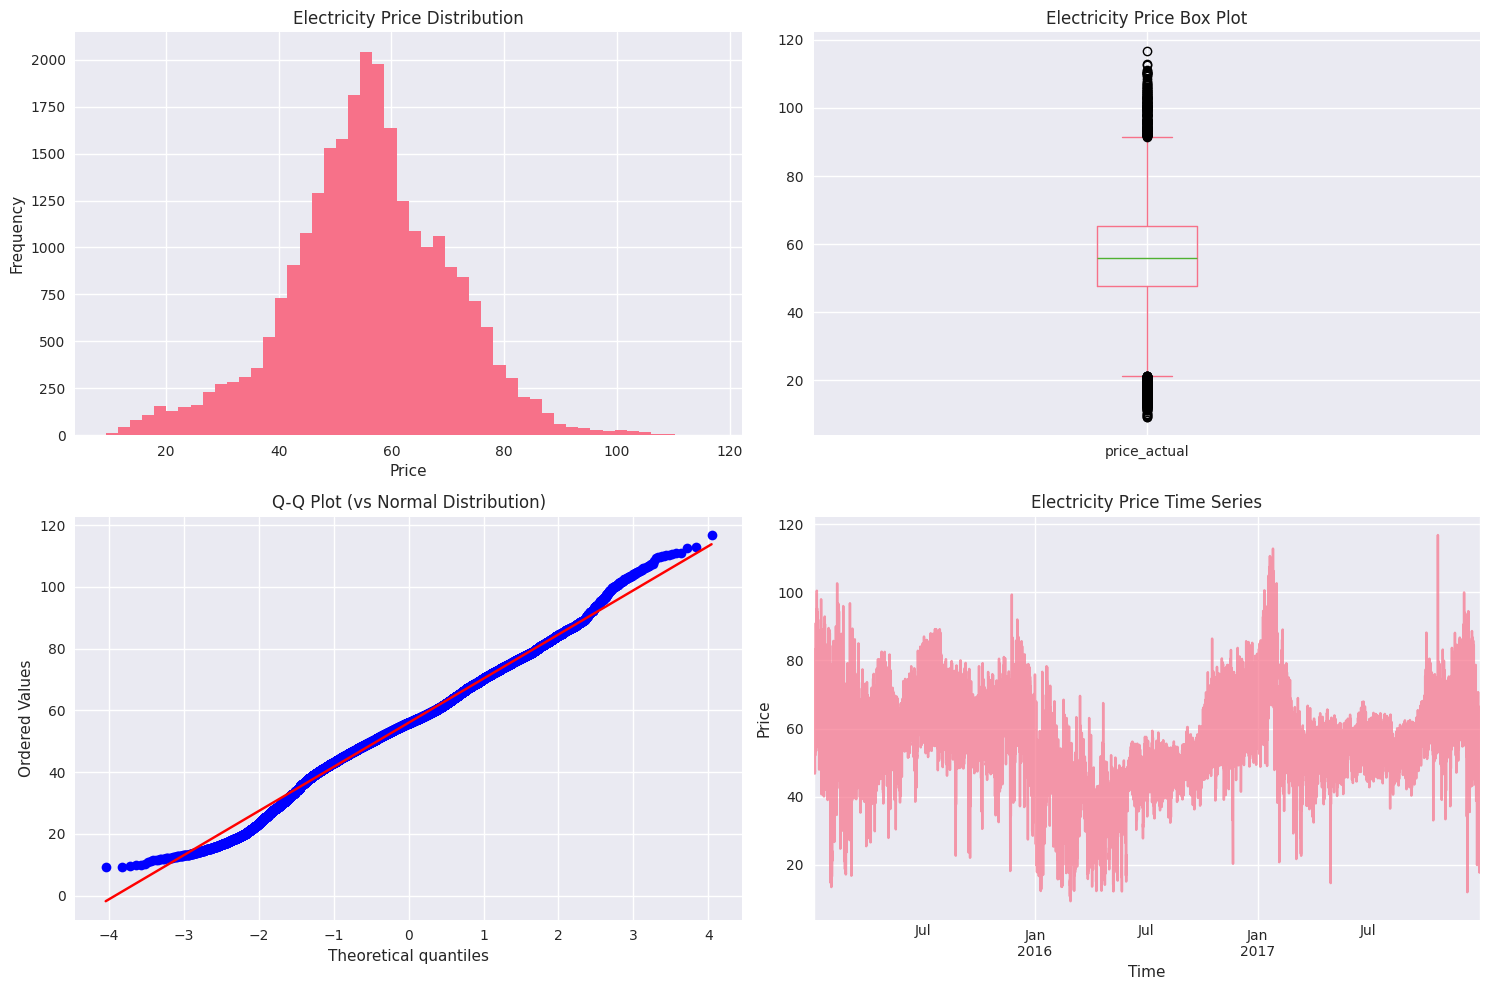


時間的パターン分析
Hourly price statistics (Top 5 hours):
         mean      std    min     max
hour                                 
21    63.9914  12.6355  21.87  111.10
20    63.9167  14.1678  16.98  112.81
19    62.5951  15.4336  16.96  116.80
18    60.5557  15.8023  14.14  110.86
22    60.4964  12.0431  17.00  106.02

Daily price statistics:
              mean      std    min     max
Monday     57.6048  14.7645  11.98  116.80
Tuesday    58.4558  13.7606  12.40  110.16
Wednesday  58.1883  14.2513  19.28  112.81
Thursday   58.3558  13.8780  16.72  107.12
Friday     58.0440  13.2624  14.70  110.63
Saturday   52.8243  13.0593  10.77  102.04
Sunday     48.7796  14.3181   9.33  100.39


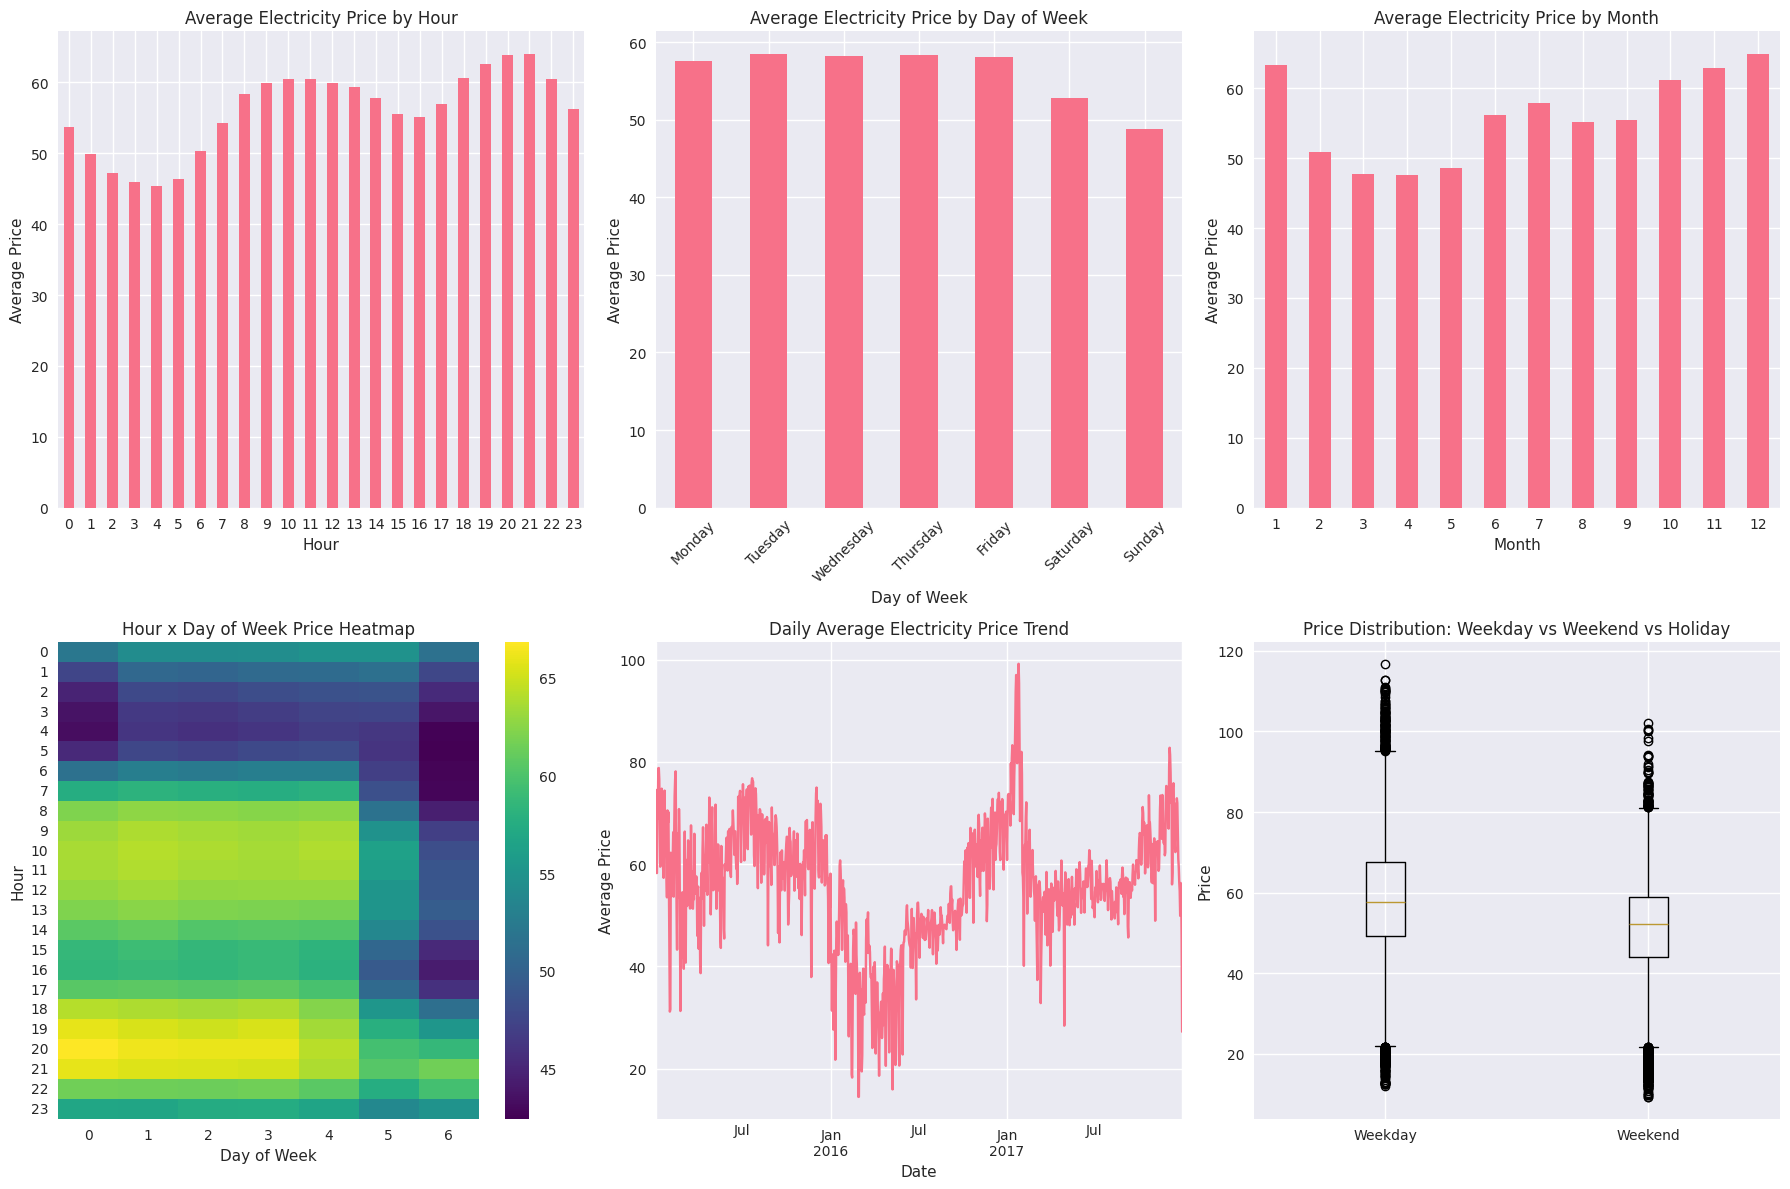


Missing Values Analysis
Columns with missing values:
                                             Missing Count  Missing Ratio (%)
price_actual                                          8760              25.00
total_load_actual                                       40               0.11
generation_biomass                                      23               0.07
generation_hydro_run_of_river_and_poundage              23               0.07
generation_hydro_pumped_storage_consumption             23               0.07
generation_waste                                        23               0.07
generation_fossil_oil                                   23               0.07
generation_fossil_hard_coal                             22               0.06
generation_hydro_water_reservoir                        22               0.06
generation_fossil_brown_coal/lignite                    22               0.06
generation_fossil_gas                                   22               0.06
generation

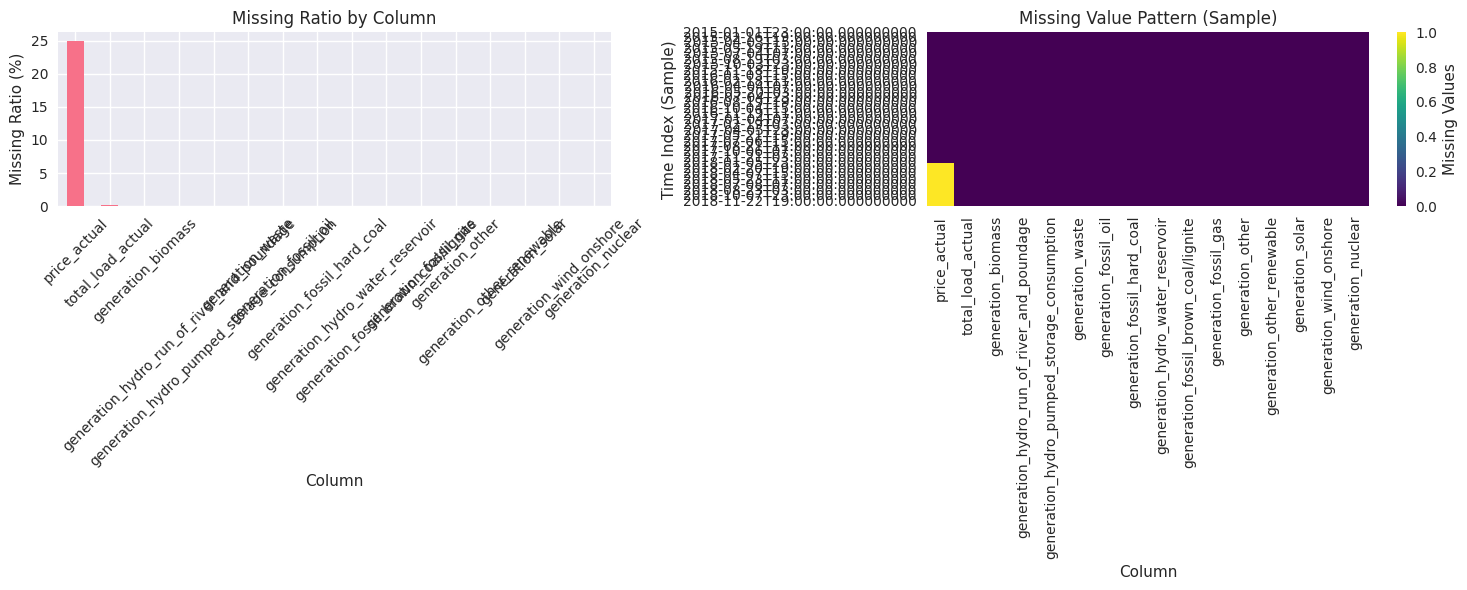


Comprehensive Feature Generation
Generating basic time features...
Generating cyclical features...
Generating lag features...
Generating rolling features...
Generating difference features...
Generating interaction features...
Generating energy-related features...
Generating weather-related features...
Generating holiday/special day features...
Generating cluster features...
Feature generation completed: 91 → 220 columns

Feature Importance Analysis
Numeric features: 204
Categorical features: 15
Categorical features will be encoded: ['valencia_weather_main', 'valencia_weather_description', 'valencia_weather_icon', 'madrid_weather_main', 'madrid_weather_description']...
Running correlation analysis...
Top 10 Pearson correlations:
                               pearson  pearson_p
price_actual_lag1               0.9656        0.0
price_actual_lag2               0.8970        0.0
price_actual_rolling_mean_6h    0.8328        0.0
price_actual_lag24              0.8233        0.0
price_actua

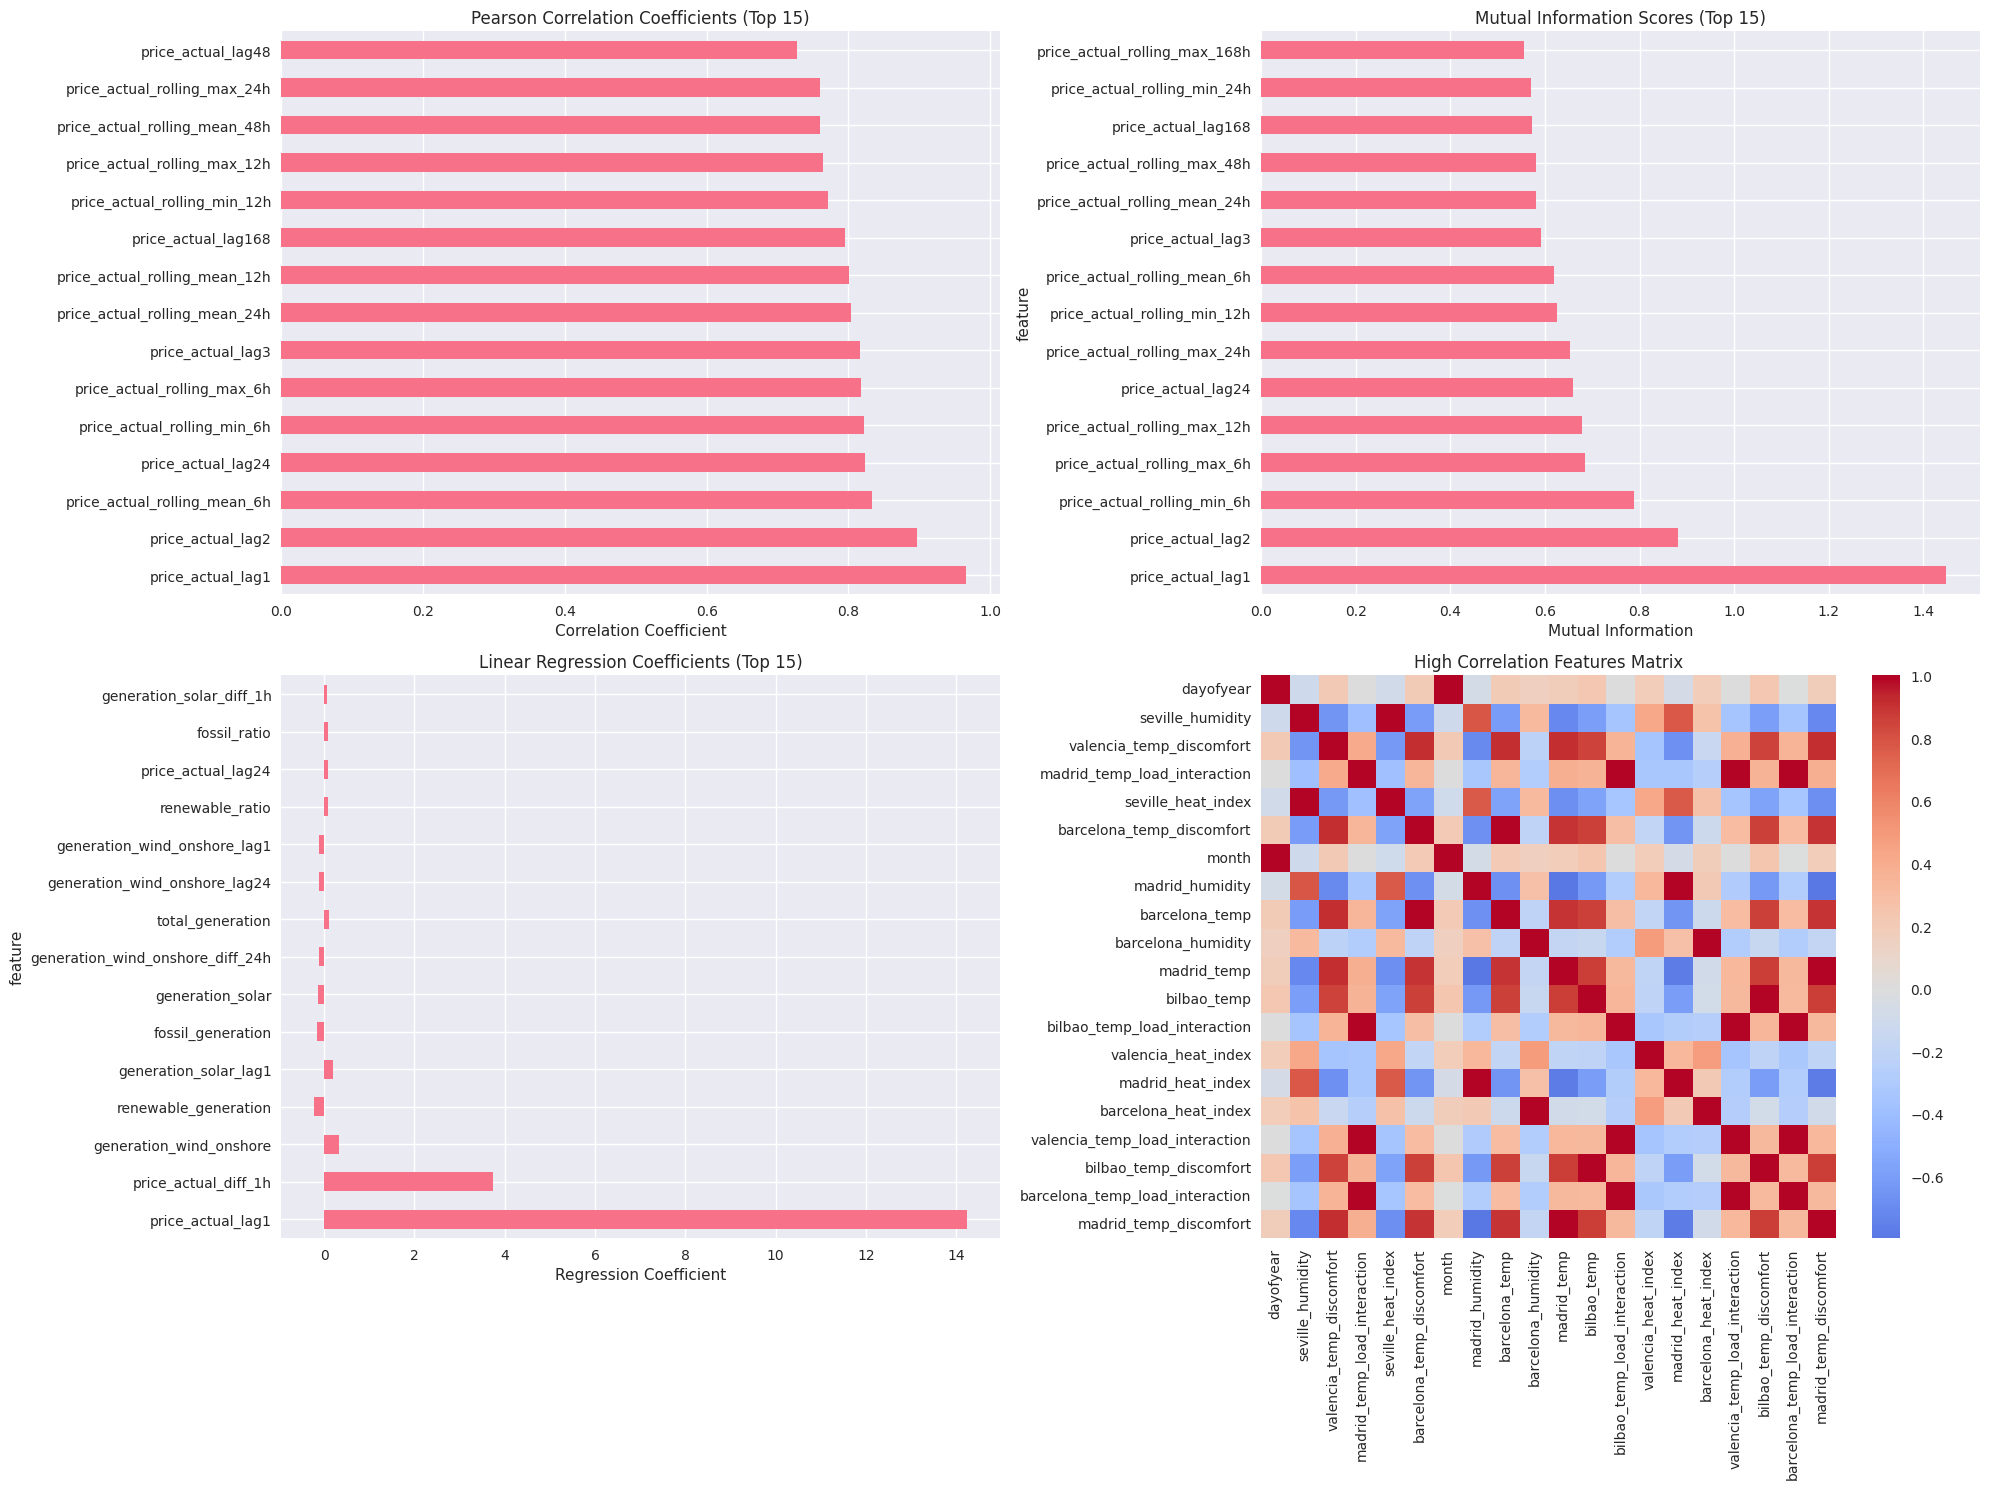


Feature Stability Analysis
Most stable features (Top 10):
                   overall_stability  mean_stability  std_stability
seville_snow_3h               1.0000          1.0000         1.0000
barcelona_snow_3h             1.0000          1.0000         1.0000
is_holiday                    1.0000          1.0000         1.0000
is_pre_holiday                1.0000          1.0000         1.0000
is_post_holiday               1.0000          1.0000         1.0000
year                          0.9998          0.9996         1.0000
hour                          0.9996          0.9995         0.9998
time_period                   0.9996          0.9994         0.9998
time_cluster                  0.9770          0.9764         0.9776
dayofweek                     0.9689          0.9647         0.9731

データリーク検出
完全相関の検出中...
未来情報特徴量の検出中...
定数特徴量の検出中...

🔍 Suspicious high correlations: 1 features
   - price_actual_lag1: 0.9656

❌ Constant features: 5 features
   - barcelona_snow_3h
   - seville

In [26]:
# ===================================================================
# 特徴量エンジニアリング分析ノートブック
# 電力価格予測コンペティション用
# ===================================================================

import os
import warnings
import gc
from datetime import datetime, timedelta
from typing import Any, Optional, Union
import pytz

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

import scipy.stats as stats
from scipy.stats import pearsonr, spearmanr

# warningsを無視
warnings.filterwarnings("ignore")

# Set matplotlib to use English
plt.rcParams['font.family'] = 'DejaVu Sans'

# 乱数シードの固定
np.random.seed(42)

# プロット設定
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


# ===================================================================
# Configuration
# ===================================================================

class AnalysisConfig:
    """分析用の設定クラス"""
    
    DATA_PATH: str = "./rawdata/"
    TARGET_COL: str = "price_actual"
    TIMEZONE: str = "Europe/Madrid"
    
    # 分析設定
    ENABLE_DETAILED_PLOTS: bool = True
    SAVE_PLOTS: bool = True
    OUTPUT_DIR: str = "./feature_analysis/"
    
    # 特徴量選択設定
    MUTUAL_INFO_THRESHOLD: float = 0.1
    CORRELATION_THRESHOLD: float = 0.95
    
    # 時系列分析設定
    SEASONAL_PERIODS: list[int] = [24, 168, 8760]  # 日、週、年の時間数
    LAG_PERIODS: list[int] = [1, 2, 3, 6, 12, 24, 48, 168]  # ラグ期間
    
    def __post_init__(self):
        """出力ディレクトリの作成"""
        os.makedirs(self.OUTPUT_DIR, exist_ok=True)


# ===================================================================
# Data Loader
# ===================================================================

class DataLoader:
    """データ読み込み・前処理クラス"""
    
    def __init__(self, config: AnalysisConfig):
        self.config = config
    
    def load_data(self) -> tuple[pd.DataFrame, pd.DataFrame]:
        """
        データを読み込み、タイムゾーン変換を行う
        
        Returns:
            tuple[pd.DataFrame, pd.DataFrame]: (train_df, test_df)
        """
        print("データの読み込み中...")
        
        train_df = pd.read_csv(self.config.DATA_PATH + 'train.csv', index_col=0)
        test_df = pd.read_csv(self.config.DATA_PATH + 'test.csv', index_col=0)
        
        # タイムゾーン変換
        train_df.index = pd.to_datetime(train_df.index, utc=True).tz_convert(self.config.TIMEZONE)
        test_df.index = pd.to_datetime(test_df.index, utc=True).tz_convert(self.config.TIMEZONE)
        
        print(f"訓練データ: {train_df.shape}, 期間: {train_df.index.min()} ~ {train_df.index.max()}")
        print(f"テストデータ: {test_df.shape}, 期間: {test_df.index.min()} ~ {test_df.index.max()}")
        
        return train_df, test_df
    
    def combine_data(self, train_df: pd.DataFrame, test_df: pd.DataFrame) -> pd.DataFrame:
        """
        訓練・テストデータを結合する（特徴量生成用）
        
        Args:
            train_df: 訓練データ
            test_df: テストデータ
            
        Returns:
            pd.DataFrame: 結合されたデータ
        """
        # テストデータには目的変数がないので、NaNで埋める
        test_df_with_target = test_df.copy()
        test_df_with_target[self.config.TARGET_COL] = np.nan
        
        combined_df = pd.concat([train_df, test_df_with_target], axis=0)
        combined_df = combined_df.sort_index()
        
        return combined_df


# ===================================================================
# Exploratory Data Analysis
# ===================================================================

class ExploratoryDataAnalyzer:
    """探索的データ分析クラス"""
    
    def __init__(self, config: AnalysisConfig):
        self.config = config
    
    def analyze_target_distribution(self, df: pd.DataFrame) -> dict[str, Any]:
        """
        目的変数の分布を分析する
        
        Args:
            df: データフレーム
            
        Returns:
            dict[str, Any]: 分析結果
        """
        print("\n" + "="*50)
        print("Target Variable (Electricity Price) Distribution Analysis")
        print("="*50)
        
        target = df[self.config.TARGET_COL].dropna()
        
        # 基本統計量
        stats_dict = {
            'count': len(target),
            'mean': target.mean(),
            'std': target.std(),
            'min': target.min(),
            'max': target.max(),
            'skewness': target.skew(),
            'kurtosis': target.kurtosis(),
            'q25': target.quantile(0.25),
            'median': target.median(),
            'q75': target.quantile(0.75),
            'iqr': target.quantile(0.75) - target.quantile(0.25)
        }
        
        print("Basic Statistics:")
        for key, value in stats_dict.items():
            print(f"  {key}: {value:.4f}")
        
        # 異常値の検出
        q1, q3 = target.quantile(0.25), target.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        
        outliers = target[(target < lower_bound) | (target > upper_bound)]
        outlier_ratio = len(outliers) / len(target) * 100
        
        print(f"\nOutlier Analysis:")
        print(f"  Lower bound: {lower_bound:.4f}, Upper bound: {upper_bound:.4f}")
        print(f"  Outliers: {len(outliers)} ({outlier_ratio:.2f}%)")
        
        # 可視化
        if self.config.ENABLE_DETAILED_PLOTS:
            fig, axes = plt.subplots(2, 2, figsize=(15, 10))
            
            # ヒストグラム
            target.hist(bins=50, ax=axes[0, 0])
            axes[0, 0].set_title('Electricity Price Distribution')
            axes[0, 0].set_xlabel('Price')
            axes[0, 0].set_ylabel('Frequency')
            
            # 箱ひげ図
            target.plot(kind='box', ax=axes[0, 1])
            axes[0, 1].set_title('Electricity Price Box Plot')
            
            # Q-Qプロット
            stats.probplot(target, dist="norm", plot=axes[1, 0])
            axes[1, 0].set_title('Q-Q Plot (vs Normal Distribution)')
            
            # 時系列プロット
            target.plot(ax=axes[1, 1], alpha=0.7)
            axes[1, 1].set_title('Electricity Price Time Series')
            axes[1, 1].set_xlabel('Time')
            axes[1, 1].set_ylabel('Price')
            
            plt.tight_layout()
            
            if self.config.SAVE_PLOTS:
                plt.savefig(f"{self.config.OUTPUT_DIR}/target_distribution_analysis.png", dpi=300, bbox_inches='tight')
            
            plt.show()
        
        return stats_dict
    
    def analyze_temporal_patterns(self, df: pd.DataFrame) -> dict[str, Any]:
        """
        時間的パターンを分析する
        
        Args:
            df: データフレーム
            
        Returns:
            dict[str, Any]: 分析結果
        """
        print("\n" + "="*50)
        print("時間的パターン分析")
        print("="*50)
        
        target = df[self.config.TARGET_COL].dropna()
        
        # 時間特徴量の作成
        df_temp = pd.DataFrame(index=target.index)
        df_temp['price'] = target
        df_temp['hour'] = df_temp.index.hour
        df_temp['dayofweek'] = df_temp.index.dayofweek
        df_temp['month'] = df_temp.index.month
        df_temp['year'] = df_temp.index.year
        df_temp['quarter'] = df_temp.index.quarter
        df_temp['is_weekend'] = (df_temp.index.dayofweek >= 5).astype(int)
        
        # スペインの祝日
        es_holidays = holidays.Spain(years=range(df_temp.index.year.min(), df_temp.index.year.max() + 1))
        df_temp['is_holiday'] = df_temp.index.normalize().isin(es_holidays).astype(int)
        
        # 季節性の分析
        seasonal_stats = {}
        
        # 時間別統計
        hourly_stats = df_temp.groupby('hour')['price'].agg(['mean', 'std', 'min', 'max']).round(4)
        seasonal_stats['hourly'] = hourly_stats
        
        # 曜日別統計
        weekday_stats = df_temp.groupby('dayofweek')['price'].agg(['mean', 'std', 'min', 'max']).round(4)
        seasonal_stats['weekday'] = weekday_stats
        
        # 月別統計
        monthly_stats = df_temp.groupby('month')['price'].agg(['mean', 'std', 'min', 'max']).round(4)
        seasonal_stats['monthly'] = monthly_stats
        
        # 平日・週末・祝日の比較
        weekend_holiday_stats = df_temp.groupby(['is_weekend', 'is_holiday'])['price'].agg(['mean', 'std', 'count']).round(4)
        seasonal_stats['weekend_holiday'] = weekend_holiday_stats
        
        print("Hourly price statistics (Top 5 hours):")
        print(hourly_stats.nlargest(5, 'mean'))
        
        print("\nDaily price statistics:")
        weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        weekday_display = weekday_stats.copy()
        weekday_display.index = weekdays
        print(weekday_display)
        
        # 可視化
        if self.config.ENABLE_DETAILED_PLOTS:
            fig, axes = plt.subplots(2, 3, figsize=(18, 12))
            
            # 時間別平均価格
            hourly_stats['mean'].plot(kind='bar', ax=axes[0, 0])
            axes[0, 0].set_title('Average Electricity Price by Hour')
            axes[0, 0].set_xlabel('Hour')
            axes[0, 0].set_ylabel('Average Price')
            axes[0, 0].tick_params(axis='x', rotation=0)
            
            # 曜日別平均価格
            weekday_display['mean'].plot(kind='bar', ax=axes[0, 1])
            axes[0, 1].set_title('Average Electricity Price by Day of Week')
            axes[0, 1].set_xlabel('Day of Week')
            axes[0, 1].set_ylabel('Average Price')
            axes[0, 1].tick_params(axis='x', rotation=45)
            
            # 月別平均価格
            monthly_stats['mean'].plot(kind='bar', ax=axes[0, 2])
            axes[0, 2].set_title('Average Electricity Price by Month')
            axes[0, 2].set_xlabel('Month')
            axes[0, 2].set_ylabel('Average Price')
            axes[0, 2].tick_params(axis='x', rotation=0)
            
            # ヒートマップ（時間×曜日）
            pivot_hour_weekday = df_temp.pivot_table(values='price', index='hour', columns='dayofweek', aggfunc='mean')
            sns.heatmap(pivot_hour_weekday, annot=False, cmap='viridis', ax=axes[1, 0])
            axes[1, 0].set_title('Hour x Day of Week Price Heatmap')
            axes[1, 0].set_xlabel('Day of Week')
            axes[1, 0].set_ylabel('Hour')
            
            # 季節性の時系列プロット
            df_temp.set_index(df_temp.index)['price'].resample('D').mean().plot(ax=axes[1, 1])
            axes[1, 1].set_title('Daily Average Electricity Price Trend')
            axes[1, 1].set_xlabel('Date')
            axes[1, 1].set_ylabel('Average Price')
            
            # 平日・週末・祝日の分布比較
            categories = []
            values = []
            for (is_weekend, is_holiday), group in df_temp.groupby(['is_weekend', 'is_holiday']):
                if is_holiday:
                    category = 'Holiday'
                elif is_weekend:
                    category = 'Weekend'
                else:
                    category = 'Weekday'
                categories.append(category)
                values.append(group['price'].values)
            
            axes[1, 2].boxplot(values, labels=categories)
            axes[1, 2].set_title('Price Distribution: Weekday vs Weekend vs Holiday')
            axes[1, 2].set_ylabel('Price')
            
            plt.tight_layout()
            
            if self.config.SAVE_PLOTS:
                plt.savefig(f"{self.config.OUTPUT_DIR}/temporal_patterns_analysis.png", dpi=300, bbox_inches='tight')
            
            plt.show()
        
        return seasonal_stats
    
    def analyze_missing_values(self, df: pd.DataFrame) -> dict[str, Any]:
        """
        欠損値を分析する
        
        Args:
            df: データフレーム
            
        Returns:
            dict[str, Any]: 欠損値分析結果
        """
        print("\n" + "="*50)
        print("Missing Values Analysis")
        print("="*50)
        
        missing_stats = {}
        missing_count = df.isnull().sum()
        missing_ratio = (missing_count / len(df) * 100).round(2)
        
        missing_df = pd.DataFrame({
            'Missing Count': missing_count,
            'Missing Ratio (%)': missing_ratio
        })
        
        # 欠損値があるカラムのみ表示
        missing_cols = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
        
        if len(missing_cols) > 0:
            print("Columns with missing values:")
            print(missing_cols)
            
            # 欠損パターンの分析
            print(f"\nMissing pattern analysis:")
            print(f"Completely missing columns: {(missing_ratio == 100).sum()}")
            print(f"Partially missing columns: {((missing_ratio > 0) & (missing_ratio < 100)).sum()}")
            
            # 可視化
            if self.config.ENABLE_DETAILED_PLOTS and len(missing_cols) > 0:
                fig, axes = plt.subplots(1, 2, figsize=(15, 6))
                
                # 欠損率の棒グラフ
                missing_cols['Missing Ratio (%)'].plot(kind='bar', ax=axes[0])
                axes[0].set_title('Missing Ratio by Column')
                axes[0].set_xlabel('Column')
                axes[0].set_ylabel('Missing Ratio (%)')
                axes[0].tick_params(axis='x', rotation=45)
                
                # 欠損値のヒートマップ（上位20カラム）
                top_missing_cols = missing_cols.head(20).index
                missing_matrix = df[top_missing_cols].isnull()
                sns.heatmap(missing_matrix.iloc[::100], # サンプリングして表示
                           cmap='viridis', ax=axes[1], cbar_kws={'label': 'Missing Values'})
                axes[1].set_title('Missing Value Pattern (Sample)')
                axes[1].set_xlabel('Column')
                axes[1].set_ylabel('Time Index (Sample)')
                
                plt.tight_layout()
                
                if self.config.SAVE_PLOTS:
                    plt.savefig(f"{self.config.OUTPUT_DIR}/missing_values_analysis.png", dpi=300, bbox_inches='tight')
                
                plt.show()
        else:
            print("No missing values found.")
        
        missing_stats['missing_summary'] = missing_df
        missing_stats['missing_columns'] = missing_cols
        
        return missing_stats


# ===================================================================
# Feature Engineering Analyzer
# ===================================================================

class FeatureEngineeringAnalyzer:
    """特徴量エンジニアリング分析クラス"""
    
    def __init__(self, config: AnalysisConfig):
        self.config = config
    
    def create_comprehensive_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        包括的な特徴量を作成する（リーク防止を考慮）
        
        Args:
            df: 入力データフレーム
            
        Returns:
            pd.DataFrame: 特徴量が追加されたデータフレーム
        """
        print("\n" + "="*50)
        print("Comprehensive Feature Generation")
        print("="*50)
        
        df_feat = df.copy()
        
        # 基本的な時間特徴量
        print("Generating basic time features...")
        df_feat = self._create_basic_time_features(df_feat)
        
        # 周期的特徴量
        print("Generating cyclical features...")
        df_feat = self._create_cyclical_features(df_feat)
        
        # ラグ特徴量（リーク防止）
        print("Generating lag features...")
        df_feat = self._create_lag_features(df_feat)
        
        # 移動統計量（リーク防止）
        print("Generating rolling features...")
        df_feat = self._create_rolling_features(df_feat)
        
        # 差分特徴量
        print("Generating difference features...")
        df_feat = self._create_diff_features(df_feat)
        
        # 交互作用特徴量
        print("Generating interaction features...")
        df_feat = self._create_interaction_features(df_feat)
        
        # エネルギー関連特徴量
        print("Generating energy-related features...")
        df_feat = self._create_energy_features(df_feat)
        
        # 気象関連特徴量
        print("Generating weather-related features...")
        df_feat = self._create_weather_features(df_feat)
        
        # 祝日・特別日特徴量
        print("Generating holiday/special day features...")
        df_feat = self._create_holiday_features(df_feat)
        
        # クラスター特徴量
        print("Generating cluster features...")
        df_feat = self._create_cluster_features(df_feat)
        
        # 無限大値をNaNに置換
        df_feat.replace([np.inf, -np.inf], np.nan, inplace=True)
        
        print(f"Feature generation completed: {df.shape[1]} → {df_feat.shape[1]} columns")
        
        return df_feat
    
    def _create_basic_time_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """基本的な時間特徴量を作成"""
        df['hour'] = df.index.hour
        df['dayofweek'] = df.index.dayofweek
        df['month'] = df.index.month
        df['year'] = df.index.year
        df['dayofyear'] = df.index.dayofyear
        df['quarter'] = df.index.quarter
        df['weekofyear'] = df.index.isocalendar().week
        df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
        
        # 時間帯の分類
        df['time_period'] = 0  # 深夜
        df.loc[df['hour'].between(6, 11), 'time_period'] = 1  # 朝
        df.loc[df['hour'].between(12, 17), 'time_period'] = 2  # 昼
        df.loc[df['hour'].between(18, 23), 'time_period'] = 3  # 夜
        
        return df
    
    def _create_cyclical_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """周期的特徴量を作成"""
        # 時間の周期性
        df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
        df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
        
        # 曜日の周期性
        df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
        df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
        
        # 月の周期性
        df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
        
        # 年内日の周期性
        df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365.25)
        df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365.25)
        
        return df
    
    def _create_lag_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """ラグ特徴量を作成（リーク防止）"""
        # 目的変数のラグ（未来の値は使用しない）
        if self.config.TARGET_COL in df.columns:
            for lag in self.config.LAG_PERIODS:
                df[f'{self.config.TARGET_COL}_lag{lag}'] = df[self.config.TARGET_COL].shift(lag)
        
        # 重要な説明変数のラグ
        lag_cols = ['total_load_actual', 'generation_solar', 'generation_wind_onshore']
        
        for col in lag_cols:
            if col in df.columns:
                for lag in [1, 24, 48, 168]:  # 1時間、1日、2日、1週間前
                    df[f'{col}_lag{lag}'] = df[col].shift(lag)
        
        return df
    
    def _create_rolling_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """移動統計量を作成（リーク防止）"""
        # 目的変数の移動統計（過去のデータのみ使用）
        if self.config.TARGET_COL in df.columns:
            for window in [6, 12, 24, 48, 168]:
                # 現在の値を除外するためmin_periods=windowに設定
                df[f'{self.config.TARGET_COL}_rolling_mean_{window}h'] = df[self.config.TARGET_COL].shift(1).rolling(window=window, min_periods=window).mean()
                df[f'{self.config.TARGET_COL}_rolling_std_{window}h'] = df[self.config.TARGET_COL].shift(1).rolling(window=window, min_periods=window).std()
                df[f'{self.config.TARGET_COL}_rolling_min_{window}h'] = df[self.config.TARGET_COL].shift(1).rolling(window=window, min_periods=window).min()
                df[f'{self.config.TARGET_COL}_rolling_max_{window}h'] = df[self.config.TARGET_COL].shift(1).rolling(window=window, min_periods=window).max()
        
        # 説明変数の移動統計
        rolling_cols = ['total_load_actual', 'generation_solar', 'generation_wind_onshore']
        
        for col in rolling_cols:
            if col in df.columns:
                for window in [6, 24, 168]:
                    df[f'{col}_rolling_mean_{window}h'] = df[col].rolling(window=window).mean()
                    df[f'{col}_rolling_std_{window}h'] = df[col].rolling(window=window).std()
        
        return df
    
    def _create_diff_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """差分特徴量を作成"""
        # 目的変数の差分（リーク防止）
        if self.config.TARGET_COL in df.columns:
            for lag in [1, 24, 168]:
                df[f'{self.config.TARGET_COL}_diff_{lag}h'] = df[self.config.TARGET_COL].diff(lag)
        
        # 説明変数の差分
        diff_cols = ['total_load_actual', 'generation_solar', 'generation_wind_onshore']
        
        for col in diff_cols:
            if col in df.columns:
                for lag in [1, 24]:
                    df[f'{col}_diff_{lag}h'] = df[col].diff(lag)
        
        return df
    
    def _create_interaction_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """交互作用特徴量を作成"""
        # 需要と供給の比率
        if 'total_load_actual' in df.columns:
            # 再生可能エネルギー比率
            renewable_cols = ['generation_solar', 'generation_wind_onshore', 'generation_hydro_run_of_river_and_poundage']
            for col in renewable_cols:
                if col in df.columns:
                    df[f'{col}_ratio'] = df[col] / (df['total_load_actual'] + 1e-8)
            
            # 需要と時間の交互作用
            df['load_hour_interaction'] = df['total_load_actual'] * df['hour']
            df['load_dayofweek_interaction'] = df['total_load_actual'] * df['dayofweek']
        
        # 気温と需要の交互作用
        temp_cols = [col for col in df.columns if '_temp' in col and 'min' not in col and 'max' not in col]
        if temp_cols and 'total_load_actual' in df.columns:
            for temp_col in temp_cols:
                df[f'{temp_col}_load_interaction'] = df[temp_col] * df['total_load_actual']
        
        return df
    
    def _create_energy_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """エネルギー関連特徴量を作成"""
        # 総発電量
        generation_cols = [col for col in df.columns if col.startswith('generation_')]
        if generation_cols:
            df['total_generation'] = df[generation_cols].sum(axis=1)
            
            # 需給バランス
            if 'total_load_actual' in df.columns:
                df['supply_demand_balance'] = df['total_generation'] - df['total_load_actual']
                df['supply_demand_ratio'] = df['total_generation'] / (df['total_load_actual'] + 1e-8)
        
        # 再生可能エネルギーの割合
        renewable_cols = ['generation_solar', 'generation_wind_onshore', 'generation_hydro_run_of_river_and_poundage']
        if all(col in df.columns for col in renewable_cols):
            df['renewable_generation'] = df[renewable_cols].sum(axis=1)
            if 'total_generation' in df.columns:
                df['renewable_ratio'] = df['renewable_generation'] / (df['total_generation'] + 1e-8)
        
        # 化石燃料発電の割合
        fossil_cols = ['generation_fossil_gas', 'generation_fossil_hard_coal', 'generation_fossil_oil']
        if all(col in df.columns for col in fossil_cols):
            df['fossil_generation'] = df[fossil_cols].sum(axis=1)
            if 'total_generation' in df.columns:
                df['fossil_ratio'] = df['fossil_generation'] / (df['total_generation'] + 1e-8)
        
        return df
    
    def _create_weather_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """気象関連特徴量を作成"""
        # 主要都市の気温データ
        cities = ['valencia', 'madrid', 'bilbao', 'barcelona', 'seville']
        
        # 平均気温
        temp_cols = [f'{city}_temp' for city in cities if f'{city}_temp' in df.columns]
        if temp_cols:
            df['avg_temp'] = df[temp_cols].mean(axis=1)
            df['max_temp_diff'] = df[temp_cols].max(axis=1) - df[temp_cols].min(axis=1)
        
        # 気温の快適度指数（冷暖房需要の代理指標）
        for city in cities:
            temp_col = f'{city}_temp'
            if temp_col in df.columns:
                # 18-25度を快適温度とした場合の不快度
                df[f'{city}_temp_discomfort'] = np.maximum(0, 18 - df[temp_col]) + np.maximum(0, df[temp_col] - 25)
        
        # 湿度と温度の組み合わせ（体感温度の代理）
        for city in cities:
            temp_col = f'{city}_temp'
            humidity_col = f'{city}_humidity'
            if temp_col in df.columns and humidity_col in df.columns:
                df[f'{city}_heat_index'] = df[temp_col] * (df[humidity_col] / 100)
        
        # 風力発電に影響する風速特徴量
        wind_speed_cols = [f'{city}_wind_speed' for city in cities if f'{city}_wind_speed' in df.columns]
        if wind_speed_cols:
            df['avg_wind_speed'] = df[wind_speed_cols].mean(axis=1)
            df['max_wind_speed'] = df[wind_speed_cols].max(axis=1)
        
        return df
    
    def _create_holiday_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """祝日・特別日特徴量を作成"""
        # スペインの祝日
        years = range(df.index.year.min(), df.index.year.max() + 1)
        es_holidays = holidays.Spain(years=years)
        
        df['is_holiday'] = df.index.normalize().isin(es_holidays).astype(int)
        
        # 祝日前後
        holiday_dates = set(es_holidays.keys())
        df['is_pre_holiday'] = (df.index.normalize() + pd.Timedelta(days=1)).isin(holiday_dates).astype(int)
        df['is_post_holiday'] = (df.index.normalize() - pd.Timedelta(days=1)).isin(holiday_dates).astype(int)
        
        # 長期休暇期間（夏休み、年末年始など）
        df['is_summer_vacation'] = ((df.index.month == 7) | (df.index.month == 8)).astype(int)
        df['is_winter_holiday'] = ((df.index.month == 12) & (df.index.day >= 20) | 
                                  (df.index.month == 1) & (df.index.day <= 10)).astype(int)
        
        return df
    
    def _create_cluster_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """クラスター特徴量を作成"""
        # 時間・曜日・月を使ったクラスタリング
        cluster_features = ['hour', 'dayofweek', 'month']
        available_features = [f for f in cluster_features if f in df.columns]
        
        if len(available_features) >= 2:
            # 正規化
            scaler = StandardScaler()
            cluster_data = scaler.fit_transform(df[available_features].fillna(0))
            
            # K-meansクラスタリング
            n_clusters = 8
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            df['time_cluster'] = kmeans.fit_predict(cluster_data)
            
            # クラスター内での相対位置
            for i in range(n_clusters):
                cluster_mask = df['time_cluster'] == i
                if cluster_mask.sum() > 0:
                    cluster_center = cluster_data[cluster_mask].mean(axis=0)
                    distances = np.linalg.norm(cluster_data[cluster_mask] - cluster_center, axis=1)
                    df.loc[cluster_mask, f'cluster_{i}_distance'] = distances
        
        return df
    
    def analyze_feature_importance(self, df: pd.DataFrame) -> dict[str, Any]:
        """
        特徴量重要度を分析する
        
        Args:
            df: 特徴量付きデータフレーム
            
        Returns:
            dict[str, Any]: 特徴量重要度分析結果
        """
        print("\n" + "="*50)
        print("Feature Importance Analysis")
        print("="*50)
        
        # 訓練データのみを使用（目的変数が存在する期間）
        train_data = df.dropna(subset=[self.config.TARGET_COL])
        
        if len(train_data) == 0:
            print("No target variable data found.")
            return {}
        
        # 特徴量と目的変数を分離
        feature_cols = [col for col in train_data.columns if col != self.config.TARGET_COL]
        
        # 数値型の特徴量のみを使用
        numeric_cols = train_data[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
        categorical_cols = train_data[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()
        
        print(f"Numeric features: {len(numeric_cols)}")
        print(f"Categorical features: {len(categorical_cols)}")
        
        if categorical_cols:
            print(f"Categorical features will be encoded: {categorical_cols[:5]}...")
            # カテゴリカル特徴量をラベルエンコーディング
            train_data_processed = train_data.copy()
            from sklearn.preprocessing import LabelEncoder
            
            for col in categorical_cols:
                le = LabelEncoder()
                train_data_processed[col] = le.fit_transform(train_data_processed[col].astype(str))
            
            # すべての特徴量を数値型として使用
            all_feature_cols = numeric_cols + categorical_cols
        else:
            train_data_processed = train_data
            all_feature_cols = numeric_cols
        
        X = train_data_processed[all_feature_cols]
        y = train_data_processed[self.config.TARGET_COL]
        
        # 欠損値を処理（数値型のみなので安全）
        X_filled = X.fillna(X.median())
        
        # 相関分析
        print("Running correlation analysis...")
        correlation_results = self._analyze_correlations(X_filled, y)
        
        # 相互情報量分析
        print("Running mutual information analysis...")
        mutual_info_results = self._analyze_mutual_information(X_filled, y)
        
        # 線形回帰による重要度
        print("Running linear regression importance analysis...")
        linear_importance = self._analyze_linear_importance(X_filled, y)
        
        # 高相関特徴量の検出
        print("Analyzing feature correlations...")
        high_corr_features = self._find_high_correlation_features(X_filled)
        
        results = {
            'correlation': correlation_results,
            'mutual_information': mutual_info_results,
            'linear_importance': linear_importance,
            'high_correlation_features': high_corr_features,
            'feature_count': len(all_feature_cols),
            'sample_count': len(train_data),
            'categorical_features': categorical_cols
        }
        
        # 結果の可視化
        if self.config.ENABLE_DETAILED_PLOTS:
            self._plot_feature_importance_analysis(results)
        
        return results
    
    def _analyze_correlations(self, X: pd.DataFrame, y: pd.Series) -> dict[str, Any]:
        """相関分析を実行"""
        correlations = {}
        
        for col in X.columns:
            if X[col].dtype in ['int64', 'float64']:
                # ピアソン相関
                pearson_corr, pearson_p = pearsonr(X[col].fillna(0), y)
                
                # スピアマン相関
                spearman_corr, spearman_p = spearmanr(X[col].fillna(0), y)
                
                correlations[col] = {
                    'pearson': pearson_corr,
                    'pearson_p': pearson_p,
                    'spearman': spearman_corr,
                    'spearman_p': spearman_p
                }
        
        # 結果をデータフレームに変換
        corr_df = pd.DataFrame(correlations).T
        corr_df['abs_pearson'] = corr_df['pearson'].abs()
        corr_df['abs_spearman'] = corr_df['spearman'].abs()
        
        # 重要な特徴量（絶対値での相関が高い）
        top_pearson = corr_df.nlargest(20, 'abs_pearson')
        top_spearman = corr_df.nlargest(20, 'abs_spearman')
        
        print(f"Top 10 Pearson correlations:")
        print(top_pearson[['pearson', 'pearson_p']].head(10).round(4))
        
        print(f"\nTop 10 Spearman correlations:")
        print(top_spearman[['spearman', 'spearman_p']].head(10).round(4))
        
        return {
            'correlation_matrix': corr_df,
            'top_pearson': top_pearson,
            'top_spearman': top_spearman
        }
    
    def _analyze_mutual_information(self, X: pd.DataFrame, y: pd.Series) -> dict[str, Any]:
        """相互情報量分析を実行"""
        # 数値特徴量のみを使用
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        X_numeric = X[numeric_cols].fillna(0)
        
        # 相互情報量を計算
        mi_scores = mutual_info_regression(X_numeric, y, random_state=42)
        
        mi_df = pd.DataFrame({
            'feature': numeric_cols,
            'mutual_info': mi_scores
        }).sort_values('mutual_info', ascending=False)
        
        # 閾値以上の特徴量
        important_features = mi_df[mi_df['mutual_info'] >= self.config.MUTUAL_INFO_THRESHOLD]
        
        print(f"Top 10 mutual information scores:")
        print(mi_df.head(10).round(4))
        
        print(f"\nFeatures above threshold ({self.config.MUTUAL_INFO_THRESHOLD}): {len(important_features)}")
        
        return {
            'mutual_info_scores': mi_df,
            'important_features': important_features
        }
    
    def _analyze_linear_importance(self, X: pd.DataFrame, y: pd.Series) -> dict[str, Any]:
        """線形回帰による特徴量重要度分析"""
        # 数値特徴量のみを使用
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        X_numeric = X[numeric_cols].fillna(0)
        
        # 標準化
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_numeric)
        
        # 線形回帰
        lr = LinearRegression()
        lr.fit(X_scaled, y)
        
        # 係数の絶対値を重要度として使用
        importance_df = pd.DataFrame({
            'feature': numeric_cols,
            'coefficient': lr.coef_,
            'abs_coefficient': np.abs(lr.coef_)
        }).sort_values('abs_coefficient', ascending=False)
        
        print(f"Top 10 linear regression importance:")
        print(importance_df[['feature', 'coefficient']].head(10).round(4))
        
        return {
            'importance_scores': importance_df,
            'r2_score': lr.score(X_scaled, y)
        }
    
    def _find_high_correlation_features(self, X: pd.DataFrame) -> dict[str, Any]:
        """高相関特徴量を検出"""
        # 数値特徴量のみ
        numeric_cols = X.select_dtypes(include=[np.number]).columns
        X_numeric = X[numeric_cols].fillna(0)
        
        # 相関行列
        corr_matrix = X_numeric.corr()
        
        # 高相関ペアを検出
        high_corr_pairs = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                corr_value = corr_matrix.iloc[i, j]
                if abs(corr_value) >= self.config.CORRELATION_THRESHOLD:
                    high_corr_pairs.append({
                        'feature1': corr_matrix.columns[i],
                        'feature2': corr_matrix.columns[j],
                        'correlation': corr_value
                    })
        
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', key=abs, ascending=False)
        
        print(f"High correlation feature pairs (threshold: {self.config.CORRELATION_THRESHOLD}):")
        if len(high_corr_df) > 0:
            print(high_corr_df.head(10))
        else:
            print("No high correlation features found.")
        
        return {
            'correlation_matrix': corr_matrix,
            'high_correlation_pairs': high_corr_df
        }
    
    def _plot_feature_importance_analysis(self, results: dict[str, Any]):
        """特徴量重要度分析の可視化"""
        fig, axes = plt.subplots(2, 2, figsize=(20, 15))
        
        # 相関の可視化
        if 'correlation' in results:
            top_corr = results['correlation']['top_pearson'].head(15)
            top_corr['pearson'].plot(kind='barh', ax=axes[0, 0])
            axes[0, 0].set_title('Pearson Correlation Coefficients (Top 15)')
            axes[0, 0].set_xlabel('Correlation Coefficient')
        
        # 相互情報量の可視化
        if 'mutual_information' in results:
            top_mi = results['mutual_information']['mutual_info_scores'].head(15)
            top_mi.set_index('feature')['mutual_info'].plot(kind='barh', ax=axes[0, 1])
            axes[0, 1].set_title('Mutual Information Scores (Top 15)')
            axes[0, 1].set_xlabel('Mutual Information')
        
        # 線形回帰重要度の可視化
        if 'linear_importance' in results:
            top_linear = results['linear_importance']['importance_scores'].head(15)
            top_linear.set_index('feature')['coefficient'].plot(kind='barh', ax=axes[1, 0])
            axes[1, 0].set_title('Linear Regression Coefficients (Top 15)')
            axes[1, 0].set_xlabel('Regression Coefficient')
        
        # 高相関特徴量のヒートマップ
        if 'high_correlation_features' in results and len(results['high_correlation_features']['high_correlation_pairs']) > 0:
            # 相関行列の一部を表示
            corr_matrix = results['high_correlation_features']['correlation_matrix']
            # 相関の高い特徴量を選択
            high_corr_features = set()
            for _, row in results['high_correlation_features']['high_correlation_pairs'].head(20).iterrows():
                high_corr_features.add(row['feature1'])
                high_corr_features.add(row['feature2'])
            
            if len(high_corr_features) > 1:
                high_corr_features = list(high_corr_features)[:20]  # 最大20個
                subset_corr = corr_matrix.loc[high_corr_features, high_corr_features]
                sns.heatmap(subset_corr, annot=False, cmap='coolwarm', center=0, ax=axes[1, 1])
                axes[1, 1].set_title('High Correlation Features Matrix')
            else:
                axes[1, 1].text(0.5, 0.5, 'No High Correlation Features', ha='center', va='center', transform=axes[1, 1].transAxes)
                axes[1, 1].set_title('High Correlation Features Matrix')
        else:
            axes[1, 1].text(0.5, 0.5, 'No High Correlation Features', ha='center', va='center', transform=axes[1, 1].transAxes)
            axes[1, 1].set_title('High Correlation Features Matrix')
        
        plt.tight_layout()
        
        if self.config.SAVE_PLOTS:
            plt.savefig(f"{self.config.OUTPUT_DIR}/feature_importance_analysis.png", dpi=300, bbox_inches='tight')
        
        plt.show()


# ===================================================================
# Feature Selection Analyzer
# ===================================================================

class FeatureSelectionAnalyzer:
    """特徴量選択分析クラス"""
    
    def __init__(self, config: AnalysisConfig):
        self.config = config
    
    def analyze_feature_stability(self, df: pd.DataFrame) -> dict[str, Any]:
        """
        特徴量の安定性を分析する（時系列での安定性）
        
        Args:
            df: 特徴量付きデータフレーム
            
        Returns:
            dict[str, Any]: 安定性分析結果
        """
        print("\n" + "="*50)
        print("Feature Stability Analysis")
        print("="*50)
        
        # 訓練データのみを使用
        train_data = df.dropna(subset=[self.config.TARGET_COL])
        
        if len(train_data) == 0:
            return {}
        
        # 特徴量カラムを取得
        feature_cols = [col for col in train_data.columns if col != self.config.TARGET_COL]
        numeric_cols = train_data[feature_cols].select_dtypes(include=[np.number]).columns
        
        stability_results = {}
        
        # 月ごとの統計量の変動を分析
        monthly_stats = {}
        for col in numeric_cols:
            monthly_data = train_data.groupby(train_data.index.to_period('M'))[col].agg(['mean', 'std', 'min', 'max'])
            
            # 統計量の変動係数（CV: Coefficient of Variation）
            cv_mean = monthly_data['mean'].std() / (monthly_data['mean'].mean() + 1e-8)
            cv_std = monthly_data['std'].std() / (monthly_data['std'].mean() + 1e-8)
            
            monthly_stats[col] = {
                'cv_mean': cv_mean,
                'cv_std': cv_std,
                'mean_stability': 1 / (1 + cv_mean),
                'std_stability': 1 / (1 + cv_std)
            }
        
        stability_df = pd.DataFrame(monthly_stats).T
        stability_df['overall_stability'] = (stability_df['mean_stability'] + stability_df['std_stability']) / 2
        stability_df = stability_df.sort_values('overall_stability', ascending=False)
        
        print("Most stable features (Top 10):")
        print(stability_df[['overall_stability', 'mean_stability', 'std_stability']].head(10).round(4))
        
        stability_results['monthly_stability'] = stability_df
        
        return stability_results
    
    def recommend_feature_improvements(self, feature_importance: dict[str, Any], 
                                     stability_analysis: dict[str, Any]) -> dict[str, Any]:
        """
        特徴量改善の推奨事項を生成する
        
        Args:
            feature_importance: 特徴量重要度分析結果
            stability_analysis: 安定性分析結果
            
        Returns:
            dict[str, Any]: 改善推奨事項
        """
        print("\n" + "="*50)
        print("特徴量改善推奨事項")
        print("="*50)
        
        recommendations = {
            'high_importance_features': [],
            'unstable_features': [],
            'redundant_features': [],
            'missing_features': [],
            'feature_engineering_suggestions': []
        }
        
        # 重要度の高い特徴量
        if 'mutual_information' in feature_importance:
            top_features = feature_importance['mutual_information']['important_features']
            recommendations['high_importance_features'] = top_features['feature'].tolist()
            print(f"✅ 重要度の高い特徴量 ({len(top_features)}個):")
            for feat in top_features['feature'].head(10):
                print(f"   - {feat}")
        
        # 不安定な特徴量
        if 'monthly_stability' in stability_analysis:
            unstable_threshold = 0.3
            unstable_features = stability_analysis['monthly_stability'][
                stability_analysis['monthly_stability']['overall_stability'] < unstable_threshold
            ]
            recommendations['unstable_features'] = unstable_features.index.tolist()
            
            if len(unstable_features) > 0:
                print(f"\n⚠️  不安定な特徴量 ({len(unstable_features)}個, 安定性 < {unstable_threshold}):")
                for feat in unstable_features.index[:10]:
                    stability_score = unstable_features.loc[feat, 'overall_stability']
                    print(f"   - {feat} (安定性: {stability_score:.3f})")
        
        # 冗長な特徴量
        if 'high_correlation_features' in feature_importance:
            high_corr_pairs = feature_importance['high_correlation_features']['high_correlation_pairs']
            if len(high_corr_pairs) > 0:
                redundant_features = set()
                for _, row in high_corr_pairs.iterrows():
                    redundant_features.add(row['feature2'])  # 相関の高いペアの片方を冗長とみなす
                
                recommendations['redundant_features'] = list(redundant_features)
                print(f"\n🔄 冗長な可能性のある特徴量 ({len(redundant_features)}個):")
                for feat in list(redundant_features)[:10]:
                    print(f"   - {feat}")
        
        # 特徴量エンジニアリング提案
        engineering_suggestions = [
            "価格の季節分解（トレンド、季節性、残差）",
            "電力需要の予測誤差を特徴量として追加",
            "ピーク時間帯とオフピーク時間帯の需給バランス差",
            "前日同時刻の価格との差分",
            "移動平均からの乖離度",
            "価格の変動率（ボラティリティ）",
            "需要予測の信頼区間",
            "気象データの予測精度指標",
            "近隣国との価格差（利用可能な場合）",
            "市場の流動性指標"
        ]
        
        recommendations['feature_engineering_suggestions'] = engineering_suggestions
        
        print(f"\n💡 新しい特徴量の提案:")
        for i, suggestion in enumerate(engineering_suggestions, 1):
            print(f"   {i}. {suggestion}")
        
        # 欠損している可能性のある重要な特徴量
        potential_missing_features = [
            "電力市場の入札データ",
            "送電網の混雑状況",
            "大規模消費者の操業スケジュール",
            "近隣国との電力取引量",
            "燃料価格（天然ガス、石炭等）",
            "CO2排出権価格",
            "経済指標（GDP、工業生産指数等）"
        ]
        
        recommendations['missing_features'] = potential_missing_features
        
        print(f"\n📊 追加検討すべきデータ:")
        for i, feature in enumerate(potential_missing_features, 1):
            print(f"   {i}. {feature}")
        
        return recommendations


# ===================================================================
# Leakage Detection  
# ===================================================================

class LeakageDetector:
    """データリーク検出クラス"""
    
    def __init__(self, config: AnalysisConfig):
        self.config = config
    
    def detect_potential_leakage(self, df: pd.DataFrame) -> dict[str, Any]:
        """
        潜在的なデータリークを検出する
        
        Args:
            df: データフレーム
            
        Returns:
            dict[str, Any]: リーク検出結果
        """
        print("\n" + "="*50)
        print("データリーク検出")
        print("="*50)
        
        train_data = df.dropna(subset=[self.config.TARGET_COL])
        
        if len(train_data) == 0:
            return {}
        
        leakage_results = {
            'perfect_correlations': [],
            'suspiciously_high_correlations': [],
            'future_information_features': [],
            'constant_features': []
        }
        
        feature_cols = [col for col in train_data.columns if col != self.config.TARGET_COL]
        target = train_data[self.config.TARGET_COL]
        
        # 完全相関の検出
        print("完全相関の検出中...")
        for col in feature_cols:
            if train_data[col].dtype in ['int64', 'float64']:
                correlation = train_data[col].corr(target)
                if abs(correlation) > 0.99:
                    leakage_results['perfect_correlations'].append({
                        'feature': col,
                        'correlation': correlation
                    })
                elif abs(correlation) > 0.9:
                    leakage_results['suspiciously_high_correlations'].append({
                        'feature': col,
                        'correlation': correlation
                    })
        
        # 未来情報の検出（特徴量名による推定）
        print("未来情報特徴量の検出中...")
        future_keywords = ['future', 'next', 'ahead', 'forward', 'lead']
        for col in feature_cols:
            if any(keyword in col.lower() for keyword in future_keywords):
                leakage_results['future_information_features'].append(col)
        
        # 定数特徴量の検出
        print("定数特徴量の検出中...")
        for col in feature_cols:
            if train_data[col].dtype in ['int64', 'float64']:
                if train_data[col].nunique() <= 1:
                    leakage_results['constant_features'].append(col)
        
        # 結果の表示
        if leakage_results['perfect_correlations']:
            print(f"⚠️  Perfect correlations: {len(leakage_results['perfect_correlations'])} features (needs review)")
            for item in leakage_results['perfect_correlations']:
                print(f"   - {item['feature']}: {item['correlation']:.6f}")
        
        if leakage_results['suspiciously_high_correlations']:
            print(f"\n🔍 Suspicious high correlations: {len(leakage_results['suspiciously_high_correlations'])} features")
            for item in leakage_results['suspiciously_high_correlations']:
                print(f"   - {item['feature']}: {item['correlation']:.4f}")
        
        if leakage_results['future_information_features']:
            print(f"\n🚨 Potential future information features: {len(leakage_results['future_information_features'])} features")
            for feat in leakage_results['future_information_features']:
                print(f"   - {feat}")
        
        if leakage_results['constant_features']:
            print(f"\n❌ Constant features: {len(leakage_results['constant_features'])} features")
            for feat in leakage_results['constant_features']:
                print(f"   - {feat}")
        
        if not any(leakage_results.values()):
            print("✅ No obvious data leakage detected.")
        
        return leakage_results


# ===================================================================
# Main Analysis Class
# ===================================================================

class FeatureAnalysisPipeline:
    """特徴量分析パイプラインのメインクラス"""
    
    def __init__(self, config: AnalysisConfig = None):
        self.config = config or AnalysisConfig()
        self.data_loader = DataLoader(self.config)
        self.eda_analyzer = ExploratoryDataAnalyzer(self.config)
        self.feature_analyzer = FeatureEngineeringAnalyzer(self.config)
        self.selection_analyzer = FeatureSelectionAnalyzer(self.config)
        self.leakage_detector = LeakageDetector(self.config)
    
    def run_comprehensive_analysis(self) -> dict[str, Any]:
        """
        包括的な特徴量分析を実行する
        
        Returns:
            dict[str, Any]: 全ての分析結果
        """
        print("特徴量エンジニアリング包括分析を開始します...")
        print("="*70)
        
        # データ読み込み
        train_df, test_df = self.data_loader.load_data()
        combined_df = self.data_loader.combine_data(train_df, test_df)
        
        # 基本的な探索的データ分析
        target_analysis = self.eda_analyzer.analyze_target_distribution(combined_df)
        temporal_analysis = self.eda_analyzer.analyze_temporal_patterns(combined_df)
        missing_analysis = self.eda_analyzer.analyze_missing_values(combined_df)
        
        # 包括的特徴量生成
        featured_df = self.feature_analyzer.create_comprehensive_features(combined_df)
        
        # 特徴量重要度分析
        importance_analysis = self.feature_analyzer.analyze_feature_importance(featured_df)
        
        # 特徴量安定性分析
        stability_analysis = self.selection_analyzer.analyze_feature_stability(featured_df)
        
        # データリーク検出
        leakage_analysis = self.leakage_detector.detect_potential_leakage(featured_df)
        
        # 改善推奨事項
        recommendations = self.selection_analyzer.recommend_feature_improvements(
            importance_analysis, stability_analysis
        )
        
        # 結果をまとめる
        analysis_results = {
            'target_distribution': target_analysis,
            'temporal_patterns': temporal_analysis,
            'missing_values': missing_analysis,
            'feature_importance': importance_analysis,
            'feature_stability': stability_analysis,
            'leakage_detection': leakage_analysis,
            'recommendations': recommendations,
            'metadata': {
                'original_features': combined_df.shape[1],
                'generated_features': featured_df.shape[1],
                'feature_increase': featured_df.shape[1] - combined_df.shape[1],
                'train_samples': len(train_df),
                'test_samples': len(test_df)
            }
        }
        
        # サマリーレポートの表示
        self._display_summary_report(analysis_results)
        
        # 結果の保存
        self._save_analysis_results(analysis_results, featured_df)
        
        return analysis_results
    
    def _display_summary_report(self, results: dict[str, Any]):
        """分析結果のサマリーレポートを表示"""
        print("\n" + "="*70)
        print("📊 Feature Analysis Summary Report")
        print("="*70)
        
        metadata = results['metadata']
        print(f"📈 Data Overview:")
        print(f"   - Training samples: {metadata['train_samples']}")
        print(f"   - Test samples: {metadata['test_samples']}")
        print(f"   - Original features: {metadata['original_features']}")
        print(f"   - Generated features: {metadata['generated_features']}")
        print(f"   - Feature increase: {metadata['feature_increase']}")
        
        # 目的変数の概要
        if 'target_distribution' in results:
            target_stats = results['target_distribution']
            print(f"\n🎯 Target Variable (Electricity Price):")
            print(f"   - Mean: {target_stats['mean']:.2f}")
            print(f"   - Std: {target_stats['std']:.2f}")
            print(f"   - Skewness: {target_stats['skewness']:.3f}")
            print(f"   - Kurtosis: {target_stats['kurtosis']:.3f}")
        
        # 重要な発見
        print(f"\n🔍 Key Findings:")
        
        # データリークの警告
        if 'leakage_detection' in results:
            leakage = results['leakage_detection']
            if leakage['perfect_correlations']:
                print(f"   ⚠️  Perfect correlations: {len(leakage['perfect_correlations'])} features (needs review)")
            if leakage['suspiciously_high_correlations']:
                print(f"   🔍 Suspicious high correlations: {len(leakage['suspiciously_high_correlations'])} features")
        
        # 安定性の問題
        if 'feature_stability' in results and 'monthly_stability' in results['feature_stability']:
            unstable_count = (results['feature_stability']['monthly_stability']['overall_stability'] < 0.3).sum()
            if unstable_count > 0:
                print(f"   📊 Unstable features: {unstable_count} features")
        
        # 推奨事項のサマリー
        if 'recommendations' in results:
            recommendations = results['recommendations']
            print(f"\n💡 Recommendations:")
            print(f"   - Important features: Focus on {len(recommendations['high_importance_features'])} features")
            print(f"   - Redundant features: Consider removing {len(recommendations['redundant_features'])} features")
            print(f"   - New features: {len(recommendations['feature_engineering_suggestions'])} suggestions")
            print(f"   - Additional data: Consider {len(recommendations['missing_features'])} types")
        
        print(f"\n📋 Next Steps:")
        print(f"   1. Review data leakage in detail")
        print(f"   2. Analyze important features in depth")
        print(f"   3. Implement new feature suggestions")
        print(f"   4. Validate with cross-validation")
        print(f"   5. Confirm model performance improvement")
        
        print("="*70)
    
    def _save_analysis_results(self, results: dict[str, Any], featured_df: pd.DataFrame):
        """分析結果を保存"""
        import json
        from datetime import datetime
        
        # タイムスタンプ付きファイル名
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        
        # 分析結果の保存（JSON serializable な部分のみ）
        serializable_results = self._make_serializable(results)
        
        with open(f"{self.config.OUTPUT_DIR}/analysis_results_{timestamp}.json", 'w', encoding='utf-8') as f:
            json.dump(serializable_results, f, indent=2, ensure_ascii=False)
        
        # 特徴量付きデータの保存（訓練データのみ）
        train_featured = featured_df.dropna(subset=[self.config.TARGET_COL])
        train_featured.to_csv(f"{self.config.OUTPUT_DIR}/featured_train_data_{timestamp}.csv")
        
        # 特徴量リストの保存
        feature_list = [col for col in featured_df.columns if col != self.config.TARGET_COL]
        with open(f"{self.config.OUTPUT_DIR}/feature_list_{timestamp}.txt", 'w', encoding='utf-8') as f:
            for feature in feature_list:
                f.write(f"{feature}\n")
        
        print(f"\n💾 Analysis results saved:")
        print(f"   - Analysis results: analysis_results_{timestamp}.json")
        print(f"   - Feature data: featured_train_data_{timestamp}.csv")
        print(f"   - Feature list: feature_list_{timestamp}.txt")
    
    def _make_serializable(self, obj: Any) -> Any:
        """オブジェクトをJSON serializable に変換"""
        if isinstance(obj, dict):
            return {k: self._make_serializable(v) for k, v in obj.items()}
        elif isinstance(obj, list):
            return [self._make_serializable(item) for item in obj]
        elif isinstance(obj, pd.DataFrame):
            return obj.to_dict('records')
        elif isinstance(obj, pd.Series):
            return obj.to_dict()
        elif isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif pd.isna(obj):
            return None
        else:
            return obj


# ===================================================================
# Advanced Feature Engineering Functions
# ===================================================================

class AdvancedFeatureGenerator:
    """高度な特徴量生成クラス"""
    
    @staticmethod
    def create_price_decomposition_features(df: pd.DataFrame, target_col: str = "price_actual") -> pd.DataFrame:
        """
        価格の季節分解特徴量を作成（リーク防止）
        
        Args:
            df: データフレーム
            target_col: 目的変数カラム名
            
        Returns:
            pd.DataFrame: 分解特徴量が追加されたデータフレーム
        """
        from statsmodels.tsa.seasonal import seasonal_decompose
        
        if target_col not in df.columns:
            return df
        
        df_result = df.copy()
        
        # 価格データを取得（欠損値を前方埋めで処理）
        price_series = df[target_col].fillna(method='ffill').fillna(method='bfill')
        
        try:
            # 季節分解（周期は1週間 = 168時間）
            decomposition = seasonal_decompose(
                price_series.dropna(), 
                model='additive', 
                period=168,
                extrapolate_trend='freq'
            )
            
            # 分解成分を特徴量として追加（1時間ずらしてリーク防止）
            df_result[f'{target_col}_trend'] = decomposition.trend.shift(1)
            df_result[f'{target_col}_seasonal'] = decomposition.seasonal.shift(1)
            df_result[f'{target_col}_residual'] = decomposition.resid.shift(1)
            
            # トレンドの変化率
            df_result[f'{target_col}_trend_change'] = decomposition.trend.diff().shift(1)
            
            # 季節成分からの乖離度
            df_result[f'{target_col}_seasonal_deviation'] = (
                (price_series - decomposition.seasonal) / (decomposition.seasonal.abs() + 1e-8)
            ).shift(1)
            
        except Exception as e:
            print(f"季節分解でエラーが発生: {e}")
        
        return df_result
    
    @staticmethod
    def create_volatility_features(df: pd.DataFrame, target_col: str = "price_actual") -> pd.DataFrame:
        """
        価格ボラティリティ特徴量を作成
        
        Args:
            df: データフレーム
            target_col: 目的変数カラム名
            
        Returns:
            pd.DataFrame: ボラティリティ特徴量が追加されたデータフレーム
        """
        if target_col not in df.columns:
            return df
        
        df_result = df.copy()
        price_series = df[target_col]
        
        # 対数収益率
        df_result[f'{target_col}_log_return'] = np.log(price_series / price_series.shift(1))
        
        # ボラティリティ（移動標準偏差）
        for window in [6, 24, 168]:
            df_result[f'{target_col}_volatility_{window}h'] = (
                df_result[f'{target_col}_log_return'].rolling(window).std().shift(1)
            )
        
        # GARCH風のボラティリティ（簡易版）
        returns = df_result[f'{target_col}_log_return'].fillna(0)
        alpha, beta = 0.1, 0.85
        
        volatility = [returns.std()]  # 初期値
        for i in range(1, len(returns)):
            vol = alpha * returns.iloc[i-1]**2 + beta * volatility[-1]**2
            volatility.append(np.sqrt(vol))
        
        df_result[f'{target_col}_garch_volatility'] = pd.Series(volatility, index=df.index).shift(1)
        
        return df_result
    
    @staticmethod
    def create_market_regime_features(df: pd.DataFrame, target_col: str = "price_actual") -> pd.DataFrame:
        """
        市場レジーム特徴量を作成（高価格・中価格・低価格期間の検出）
        
        Args:
            df: データフレーム
            target_col: 目的変数カラム名
            
        Returns:
            pd.DataFrame: 市場レジーム特徴量が追加されたデータフレーム
        """
        if target_col not in df.columns:
            return df
        
        df_result = df.copy()
        price_series = df[target_col]
        
        # 移動平均との比較でレジーム判定
        for window in [24, 168]:
            ma = price_series.rolling(window).mean()
            df_result[f'{target_col}_above_ma_{window}h'] = (price_series > ma).astype(int).shift(1)
            
            # 移動平均からの乖離率
            df_result[f'{target_col}_ma_deviation_{window}h'] = (
                (price_series - ma) / (ma + 1e-8)
            ).shift(1)
        
        # 価格の分位数ベースでのレジーム
        rolling_window = 168 * 4  # 4週間
        for q in [0.2, 0.8]:
            quantile = price_series.rolling(rolling_window).quantile(q)
            if q == 0.2:
                df_result[f'{target_col}_low_regime'] = (price_series <= quantile).astype(int).shift(1)
            else:
                df_result[f'{target_col}_high_regime'] = (price_series >= quantile).astype(int).shift(1)
        
        return df_result


# ===================================================================
# Feature Validation
# ===================================================================

class FeatureValidator:
    """特徴量検証クラス"""
    
    def __init__(self, config: AnalysisConfig):
        self.config = config
    
    def validate_time_series_features(self, df: pd.DataFrame) -> dict[str, Any]:
        """
        時系列特徴量の検証（リーク検出含む）
        
        Args:
            df: データフレーム
            
        Returns:
            dict[str, Any]: 検証結果
        """
        print("\n" + "="*50)
        print("時系列特徴量検証")
        print("="*50)
        
        validation_results = {
            'leakage_suspicious_features': [],
            'high_autocorr_features': [],
            'future_looking_features': [],
            'validation_passed': True
        }
        
        train_data = df.dropna(subset=[self.config.TARGET_COL])
        feature_cols = [col for col in train_data.columns if col != self.config.TARGET_COL]
        
        # 各特徴量について将来リークの可能性をチェック
        for col in feature_cols:
            if train_data[col].dtype in ['int64', 'float64']:
                # 特徴量と1期先の目的変数との相関をチェック
                future_target = train_data[self.config.TARGET_COL].shift(-1)
                current_feature = train_data[col]
                
                # 有効なペアのみで相関を計算
                valid_mask = ~(current_feature.isna() | future_target.isna())
                if valid_mask.sum() > 10:  # 最低10個のデータポイントが必要
                    correlation = current_feature[valid_mask].corr(future_target[valid_mask])
                    
                    # 現在の特徴量と現在の目的変数の相関
                    current_correlation = current_feature.corr(train_data[self.config.TARGET_COL])
                    
                    # 将来との相関が現在との相関より著しく高い場合は疑わしい
                    if abs(correlation) > abs(current_correlation) + 0.1 and abs(correlation) > 0.5:
                        validation_results['leakage_suspicious_features'].append({
                            'feature': col,
                            'future_correlation': correlation,
                            'current_correlation': current_correlation
                        })
                        validation_results['validation_passed'] = False
        
        # 自己相関の高い特徴量の検出
        for col in feature_cols:
            if train_data[col].dtype in ['int64', 'float64']:
                series = train_data[col].dropna()
                if len(series) > 50:
                    # 1期ラグの自己相関
                    autocorr = series.autocorr(lag=1)
                    if abs(autocorr) > 0.95:
                        validation_results['high_autocorr_features'].append({
                            'feature': col,
                            'autocorrelation': autocorr
                        })
        
        # 結果の表示
        if validation_results['leakage_suspicious_features']:
            print("⚠️  Features suspected of leakage:")
            for item in validation_results['leakage_suspicious_features']:
                print(f"   - {item['feature']}: future_corr={item['future_correlation']:.4f}, current_corr={item['current_correlation']:.4f}")
        
        if validation_results['high_autocorr_features']:
            print(f"\n📈 High autocorrelation features:")
            for item in validation_results['high_autocorr_features']:
                print(f"   - {item['feature']}: autocorr={item['autocorrelation']:.4f}")
        
        if validation_results['validation_passed']:
            print("✅ Time series feature validation passed.")
        else:
            print("❌ Issues detected in time series features.")
        
        return validation_results


# ===================================================================
# Usage Example and Main Execution
# ===================================================================

def main():
    """メイン実行関数"""
    
    # 設定
    config = AnalysisConfig()
    config.ENABLE_DETAILED_PLOTS = True
    config.SAVE_PLOTS = True
    
    # 分析パイプラインの実行
    pipeline = FeatureAnalysisPipeline(config)
    
    print("🚀 特徴量エンジニアリング包括分析を開始...")
    results = pipeline.run_comprehensive_analysis()
    
    # 高度な特徴量生成の例
    print("\n" + "="*50)
    print("高度な特徴量生成の実行例")
    print("="*50)
    
    # データの再読み込み
    train_df, test_df = pipeline.data_loader.load_data()
    combined_df = pipeline.data_loader.combine_data(train_df, test_df)
    
    # 高度な特徴量の生成
    advanced_generator = AdvancedFeatureGenerator()
    
    print("価格分解特徴量を生成中...")
    combined_df = advanced_generator.create_price_decomposition_features(combined_df)
    
    print("ボラティリティ特徴量を生成中...")
    combined_df = advanced_generator.create_volatility_features(combined_df)
    
    print("市場レジーム特徴量を生成中...")
    combined_df = advanced_generator.create_market_regime_features(combined_df)
    
    # 特徴量検証
    validator = FeatureValidator(config)
    validation_results = validator.validate_time_series_features(combined_df)
    
    print(f"\n✅ Advanced feature analysis completed.")
    print(f"   - Original features: {train_df.shape[1]}")
    print(f"   - Final features: {combined_df.shape[1]}")
    print(f"   - Feature increase: {combined_df.shape[1] - train_df.shape[1]}")
    
    # 最終的な推奨事項
    print("\n" + "="*70)
    print("🎯 Final Recommendations")
    print("="*70)
    print("1. Integrate detected important features into original pipeline")
    print("2. Remove features suspected of data leakage")
    print("3. Add advanced features (decomposition, volatility, regime)")
    print("4. Validate new feature effectiveness with cross-validation")
    print("5. Confirm model performance improvement")
    print("="*70)
    
    return results


if __name__ == "__main__":
    main()


# ===================================================================
# テスト用の簡易実行関数
# ===================================================================

def quick_analysis():
    """クイック分析用の関数（プロット無効）"""
    config = AnalysisConfig()
    config.ENABLE_DETAILED_PLOTS = False
    config.SAVE_PLOTS = False
    
    pipeline = FeatureAnalysisPipeline(config)
    return pipeline.run_comprehensive_analysis()


def analyze_specific_features(feature_names: list[str]):
    """特定の特徴量のみを詳細分析する関数"""
    config = AnalysisConfig()
    
    # データ読み込み
    data_loader = DataLoader(config)
    train_df, test_df = data_loader.load_data()
    combined_df = data_loader.combine_data(train_df, test_df)
    
    # 指定された特徴量のみを分析
    analysis_features = [config.TARGET_COL] + feature_names
    subset_df = combined_df[analysis_features]
    
    # 特徴量重要度分析
    feature_analyzer = FeatureEngineeringAnalyzer(config)
    importance_results = feature_analyzer.analyze_feature_importance(subset_df)
    
    return importance_results


# ===================================================================
# Jupyter Notebook用のヘルパー関数
# ===================================================================

def display_feature_analysis_summary(results: dict[str, Any]):
    """分析結果のサマリーを見やすく表示する関数"""
    from IPython.display import display, HTML
    
    # HTML形式でサマリーを作成
    html_content = f"""
    <div style="border: 2px solid #4CAF50; padding: 20px; border-radius: 10px; background-color: #f9f9f9;">
        <h2 style="color: #4CAF50; text-align: center;">📊 特徴量分析サマリー</h2>
        
        <h3>🎯 目的変数統計:</h3>
        <ul>
            <li>平均: {results['target_distribution']['mean']:.2f}</li>
            <li>標準偏差: {results['target_distribution']['std']:.2f}</li>
            <li>歪度: {results['target_distribution']['skewness']:.3f}</li>
        </ul>
        
        <h3>🔍 重要な発見:</h3>
        <ul>
            <li>生成特徴量数: {results['metadata']['feature_increase']}</li>
            <li>重要特徴量: {len(results['recommendations']['high_importance_features'])}個</li>
            <li>冗長特徴量: {len(results['recommendations']['redundant_features'])}個</li>
        </ul>
        
        <h3>💡 次のアクション:</h3>
        <ol>
            <li>重要特徴量をモデルに統合</li>
            <li>冗長特徴量の除去を検討</li>
            <li>新しい特徴量のアイデアを実装</li>
            <li>クロスバリデーションで効果検証</li>
        </ol>
    </div>
    """
    
    display(HTML(html_content))